# Electricity Incident Prediction: Results

This notebook summarizes the training pipeline, model comparison, and the operational threshold selection for the incident prediction system.

## 1. Training Pipeline Overview

### Data Split Strategy
We use **chronological time-series split** to prevent information leakage:
- **Training (2021–2023)**: Historical data for model learning.
- **Validation (2024)**: Used to select the operating threshold.
- **Test (2025)**: Held out for final unbiased performance reporting.

### Hyperparameter Tuning
Logistic Regression and Random Forest are tuned using **TimeSeriesSplit cross-validation** (4 folds) with **F2 scoring** (recall-weighted).
  
### Why F2 Score?
In incident detection, **missing an incident is more costly than false alerts**. F2 gives recall **twice the weight** of precision:
$$F_2 = \frac{5 \times \text{Precision} \times \text{Recall}}{4 \times \text{Precision} + \text{Recall}}$$

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Setup paths
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

# Import training utilities
from models.train_baseline import (
    load_config,
    split_time,
    tune_model,
    pick_threshold_with_min_precision,
    build_threshold_tradeoff,
)

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Dependencies loaded.")

Dependencies loaded.


In [3]:
# Load configuration and data
cfg = load_config()
data_path = ROOT / "data" / "processed" / "supervised_2021_2025.csv"
data = pd.read_csv(data_path)

feature_cols = [c for c in data.columns if c.startswith("lag_")]
print(f"Loaded {len(data)} samples with {len(feature_cols)} lag features.")

# Split data
train_df, valid_df, test_df = split_time(
    data,
    train_end=cfg["split"]["train_end"],
    valid_end=cfg["split"]["valid_end"],
    timezone=cfg["data"]["timezone"],
)

x_train, y_train = train_df[feature_cols].to_numpy(), train_df["target"].to_numpy()
x_valid, y_valid = valid_df[feature_cols].to_numpy(), valid_df["target"].to_numpy()
x_test, y_test = test_df[feature_cols].to_numpy(), test_df["target"].to_numpy()

print(f"Train: {len(x_train)} | Validation: {len(x_valid)} | Test: {len(x_test)}")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test): {np.bincount(y_test)}")

Loaded 43650 samples with 168 lag features.
Train: 26112 | Validation: 8784 | Test: 8754
Class distribution (train): [22182  3930]
Class distribution (test): [7271 1483]


## 2. Model Comparison: Logistic Regression vs. Random Forest

Both models are trained on the same data with F2-optimized hyperparameters. We compare them on the test set using a common threshold policy (min precision = 0.30).

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, fbeta_score

# Train Logistic Regression
lr_base = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=cfg["model"]["random_state"],
            ),
        ),
    ]
)

lr_param_dist = {
    "clf__C": [0.01, 0.1, 1.0, 5.0, 10.0, 20.0],
    "clf__solver": ["lbfgs", "liblinear"],
}

lr, lr_best_params, lr_best_score = tune_model(
    estimator=lr_base,
    param_distributions=lr_param_dist,
    x_train=x_train,
    y_train=y_train,
    random_state=cfg["model"]["random_state"],
    n_iter=8,
)

print("Logistic Regression Training Complete")
print(f"Best CV-F2 Score: {lr_best_score:.4f}")
print(f"Best Parameters: {lr_best_params}")

Logistic Regression Training Complete
Best CV-F2 Score: 0.5243
Best Parameters: {'clf__solver': 'liblinear', 'clf__C': 10.0}


In [5]:
# Train Random Forest
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=cfg["model"]["random_state"],
    n_jobs=-1,
)

rf_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", "log2", None],
}

rf, rf_best_params, rf_best_score = tune_model(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    x_train=x_train,
    y_train=y_train,
    random_state=cfg["model"]["random_state"],
    n_iter=12,
)

print("Random Forest Training Complete")
print(f"Best CV-F2 Score: {rf_best_score:.4f}")
print(f"Best Parameters: {rf_best_params}")

Random Forest Training Complete
Best CV-F2 Score: 0.3343
Best Parameters: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 8}


In [6]:
# Get test predictions for both models
valid_proba_lr = lr.predict_proba(x_valid)[:, 1]
test_proba_lr = lr.predict_proba(x_test)[:, 1]

valid_proba_rf = rf.predict_proba(x_valid)[:, 1]
test_proba_rf = rf.predict_proba(x_test)[:, 1]

# Compare test metrics at the same threshold (0.3 min precision)
min_precision_target = 0.30
thr_lr = pick_threshold_with_min_precision(y_valid, valid_proba_lr, min_precision=min_precision_target, beta=2.0)
thr_rf = pick_threshold_with_min_precision(y_valid, valid_proba_rf, min_precision=min_precision_target, beta=2.0)

y_pred_lr = (test_proba_lr >= thr_lr).astype(int)
y_pred_rf = (test_proba_rf >= thr_rf).astype(int)

# Compute key metrics
from sklearn.metrics import average_precision_score, fbeta_score

metrics_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "CV-F2": [lr_best_score, rf_best_score],
    "Threshold": [thr_lr, thr_rf],
    "PR-AUC": [
        average_precision_score(y_test, test_proba_lr),
        average_precision_score(y_test, test_proba_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    "F2": [
        fbeta_score(y_test, y_pred_lr, beta=2, zero_division=0),
        fbeta_score(y_test, y_pred_rf, beta=2, zero_division=0),
    ],
})

print("\nTest Set Comparison (at min precision = 0.30):")
print(metrics_comparison.to_string(index=False))


Test Set Comparison (at min precision = 0.30):
              Model    CV-F2  Threshold   PR-AUC  Precision   Recall       F2
Logistic Regression 0.524284   0.389252 0.420124   0.265680 0.919757 0.616302
      Random Forest 0.334325   0.429415 0.344608   0.270492 0.756575 0.556548


### Model Selection Decision

**Logistic Regression is superior** for this task, as it obtains much higher PR-AUC, Recall and F2 for slightly lower precision.

## 3. Precision-Recall Tradeoff Analysis

We can control the precision-recall tradeoff by adjusting the classification threshold.
Higher thresholds → higher precision, lower recall (fewer alerts, but higher confidence in them).
Lower thresholds → lower precision, higher recall (more alerts, catch more incidents).

In [13]:
# Build threshold tradeoff table for LR
from IPython.display import display

tradeoff_lr = build_threshold_tradeoff(y_valid, valid_proba_lr, beta=2.0)

# Focus on reasonable precision range
reasonable_tradeoff = tradeoff_lr[tradeoff_lr["precision"] >= 0.20].copy()

# Sample key thresholds for display
key_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40]
display_table = []

for min_prec in key_thresholds:
    threshold = pick_threshold_with_min_precision(y_valid, valid_proba_lr, min_precision=min_prec, beta=2.0)
    y_pred_temp = (valid_proba_lr >= threshold).astype(int)
    p = precision_score(y_valid, y_pred_temp, zero_division=0)
    r = recall_score(y_valid, y_pred_temp, zero_division=0)
    display_table.append({
        "Min Precision Target": min_prec,
        "Achieved Threshold": threshold,
        "Actual Precision": p,
        "Recall": r,
    })

tradeoff_display = pd.DataFrame(display_table)
print("\nValidation Set: Precision-Recall Tradeoff (Logistic Regression)")
display(
    tradeoff_display.style
    .hide(axis="index")
    .format({
        "Min Precision Target": "{:.2f}",
        "Achieved Threshold": "{:.4f}",
        "Actual Precision": "{:.4f}",
        "Recall": "{:.4f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": "text-align: center; font-weight: bold;"},
    ])
)


Validation Set: Precision-Recall Tradeoff (Logistic Regression)


Min Precision Target,Achieved Threshold,Actual Precision,Recall
0.20,0.1892,0.2000,0.9838
0.25,0.3123,0.2500,0.9405
0.30,0.3893,0.3000,0.8596
0.35,0.4555,0.3501,0.7620
0.40,0.5442,0.4000,0.5498


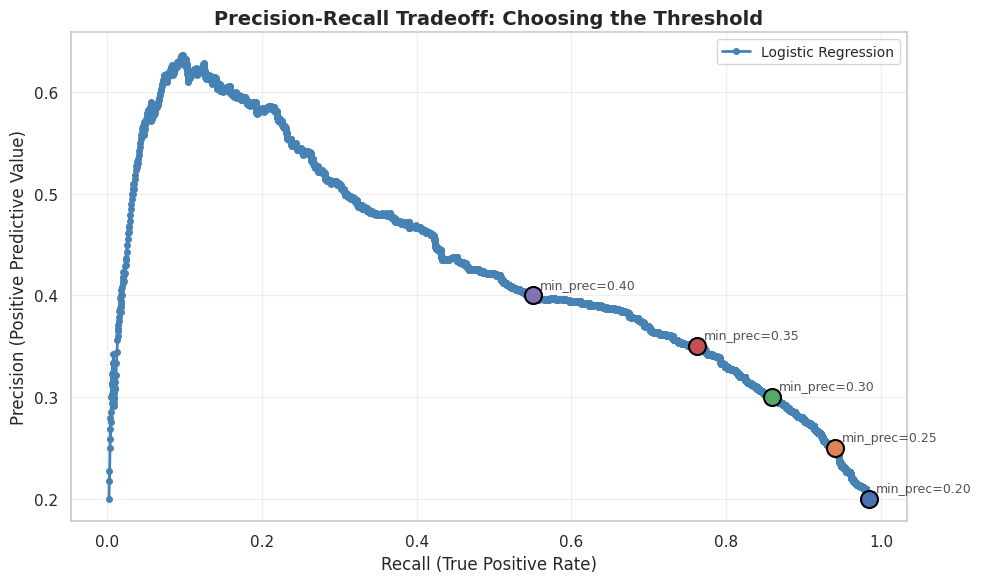


Visualization shows how different min-precision targets affect recall.


In [14]:
# Visualize the precision-recall tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    reasonable_tradeoff["recall"],
    reasonable_tradeoff["precision"],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=4,
    label="Logistic Regression",
    color="steelblue",
)

# Highlight key operating points
for min_prec in key_thresholds:
    threshold = pick_threshold_with_min_precision(y_valid, valid_proba_lr, min_precision=min_prec, beta=2.0)
    y_pred_temp = (valid_proba_lr >= threshold).astype(int)
    p = precision_score(y_valid, y_pred_temp, zero_division=0)
    r = recall_score(y_valid, y_pred_temp, zero_division=0)
    ax.scatter(r, p, s=150, zorder=5, edgecolors="black", linewidth=1.5)
    ax.annotate(
        f"min_prec={min_prec:.2f}",
        xy=(r, p),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        alpha=0.8,
    )

ax.set_xlabel("Recall (True Positive Rate)", fontsize=12)
ax.set_ylabel("Precision (Positive Predictive Value)", fontsize=12)
ax.set_title("Precision-Recall Tradeoff: Choosing the Threshold", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nVisualization shows how different min-precision targets affect recall.")

## 4. Threshold Selection Justification

### Decision: Min Precision = 0.30

We evaluated the operating points for min precision targets **0.20, 0.25, 0.30, 0.35, and 0.40**.

We choose **min_precision = 0.30** because it provides the best practical balance:
- materially better precision than 0.20 and 0.25,
- without the sharp recall loss observed at 0.35 and 0.40,
- aligned with incident-detection priorities where missing true incidents is costly.

## 5. Final Test Performance

With the chosen operating threshold (min_precision = 0.30), here is the test-set performance:

In [12]:
# Final test metrics with chosen threshold
thr_chosen = pick_threshold_with_min_precision(y_valid, valid_proba_lr, min_precision=0.30, beta=2.0)
y_pred_test = (test_proba_lr >= thr_chosen).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

p_test = precision_score(y_test, y_pred_test, zero_division=0)
r_test = recall_score(y_test, y_pred_test, zero_division=0)
f2_test = fbeta_score(y_test, y_pred_test, beta=2, zero_division=0)
prauc_test = average_precision_score(y_test, test_proba_lr)

print(f"\n{'='*60}")
print(f"{'FINAL TEST PERFORMANCE (Logistic Regression)':^60}")
print(f"{'='*60}")
print(f"\nOperating Threshold:  {thr_chosen:.4f}")
print(f"Min Precision Target: 0.30")
print(f"\nMetrics:")
print(f"  PR-AUC:    {prauc_test:.4f}")
print(f"  Precision: {p_test:.4f}")
print(f"  Recall:    {r_test:.4f}")
print(f"  F2 Score:  {f2_test:.4f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

print(f"\nInterpretation:")
print(f"  - Caught {tp} out of {tp + fn} incidents ({r_test:.1%})")
print(f"  - Out of {fp + tp} alerts, {tp} were correct ({p_test:.1%})")


        FINAL TEST PERFORMANCE (Logistic Regression)        

Operating Threshold:  0.3893
Min Precision Target: 0.30

Metrics:
  PR-AUC:    0.4201
  Precision: 0.2657
  Recall:    0.9198
  F2 Score:  0.6163

Confusion Matrix:
[[3501 3770]
 [ 119 1364]]

  True Negatives:  3501
  False Positives: 3770
  False Negatives: 119
  True Positives:  1364

Interpretation:
  - Caught 1364 out of 1483 incidents (92.0%)
  - Out of 5134 alerts, 1364 were correct (26.6%)


## Conclusions

The model is suitable for proactive alerts to reduce incident risk by prioritizing recall over precision. 

However, performance can be improved (particularly false alarms) by further iteration on models, features and class imbalance workarounds.